In [1]:
import sys
from pathlib import Path

import polars as pl
import torch
from torchvision.transforms import v2 as transforms

this_path = Path(__file__) if '__file__' in globals() else Path("<undefined>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

ee_tools_path_p = work_path / Path("ee")
sys.path.append(str(ee_tools_path_p))

import utils
import pl_utils
from datasets import fetch_handler
from ee_tools.ee_refiner import EERefiner
from network import Network, Networks
from exp_manager import ExpManager
from torchvision import models
from analyzer import Analyzer


In [2]:
pl_utils.Config()
exp_path = this_path.parent
exp_mgr = ExpManager(exp_path=exp_path)

df = exp_mgr.fetch_results(refresh=False)
df = df.filter(pl.col("epochs") == pl.col("epoch").list.last())

red = "r"
ipc = "IPC"
ndata = "Data Size"

df = df.filter(pl.col("optimizer") == "AdamW")
df = df.with_columns((pl.col("train_ndata") // pl.col("num_classes")).alias("ipc"))

df = df.rename({"div": red, "ipc": ipc, "train_ndata": ndata})

print(df)

shape: (4, 43)
┌───────────────────────────┬───────────┬────────────────┬──────────────┬─────────────┬───────────────────────────┬───────────────────────────┬───────────┬───────────┬────────┬────────┬──────┬────────────┬─────────────┬─────────────┬───────┬─────────────────┬─────────────────┬─────┬───────────┬──────────┬────────────┬──────────────────┬───────────┬───────────────────┬───────────┬────────────────┬────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬──────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬─────┐
│ run_id                    ┆ model_arc ┆ train_dataset  ┆ val_dataset  ┆ num_classes ┆ train_trans               ┆ val_trans                 ┆ Data Size ┆ val_ndata ┆ epo

In [3]:
runs_data = df.to_dicts()

ds_root = work_path / "assets/datasets/"
base_train_ds = fetch_handler(ds_root, "cifar100_train")
base_val_ds = fetch_handler(ds_root, "cifar100_test")
# base_val_ds = fetch_handler(ds_root, "cifar100_train")

val_trans = [transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True), base_train_ds.normalizer()]
val_ds = base_val_ds.transform(val_trans)
val_dl = val_ds.loader(batch_size=128)


In [4]:
# runs_data = runs_data[:1]
for run_data in runs_data:
    run_mgr = exp_mgr.get_run(run_data["run_id"])
    sd = torch.load(run_mgr.fpath("state_dict.pt"))

    net_cls = getattr(models, run_data["model_arc"])
    num_classes = run_data["num_classes"]
    div = run_data[red]

    network = Network(EERefiner(net_cls(num_classes=num_classes)).cifar_style().multi_narrow(div=div, agg="mean").init_weights().build())
    network.load_state_dict_flexible(sd)

    results = (
        Analyzer(network)
            .calc_activation_rate(key="activation_rate", layer_pattern=r".*relu.*", with_avg=True, with_layer=True, with_path=True, with_layer_path=True, with_counts=True)
            # .calc_channel_survival_rate(key="channel_survival_rate", layer_pattern=r".*relu.*", with_avg=True, with_layer=True, with_path=True, with_layer_path=True, with_counts=True)
            .calc_dead_neuron_ratio(key="dead_neuron_ratio", layer_pattern=r".*relu.*", with_avg=True, with_layer=True, with_path=True, with_layer_path=True, with_counts=True)
            .calc_magnitude(key="magnitude", layer_pattern=r".*relu.*", threshold=1e-6, with_avg=True, with_layer=True, with_path=True, with_layer_path=True, with_counts=True)
            .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", channels=16, with_avg=True, with_layer=True, with_group_info=True)
            # .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", groups=8, with_avg=True, with_layer=True, with_group_info=True)
            # .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", groups=4*div, with_avg=True, with_layer=True, with_group_info=True)
            .calc_eval(key="eval", with_ens=True, with_path=True, with_oracle=True, cumulative_modes=["original", "loss_asc", "loss_desc", "acc_desc", "acc_asc"])
            .flow(val_dl)
    )
    
    
    run_data |= results

    # run_mgr.log_param("fire_rate", avg)
    # run_mgr.sync()
    # torch.save(layer_rates, run_mgr.fpath("layer_rates.pt"))
    # torch.save(layer_neurons, run_mgr.fpath("layer_neurons.pt"))

    # print(avg)
    # print(layer_rates)
    # print(layer_neurons)
# exp_mgr.ref_results()


activation_rate


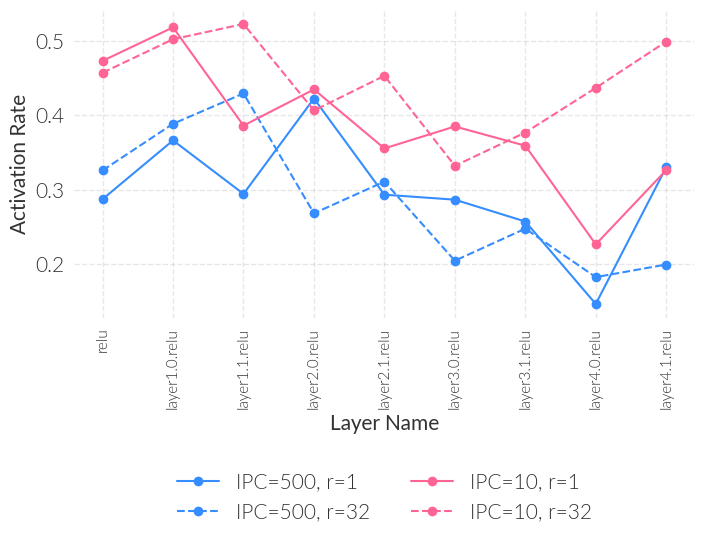

dead_neuron_ratio


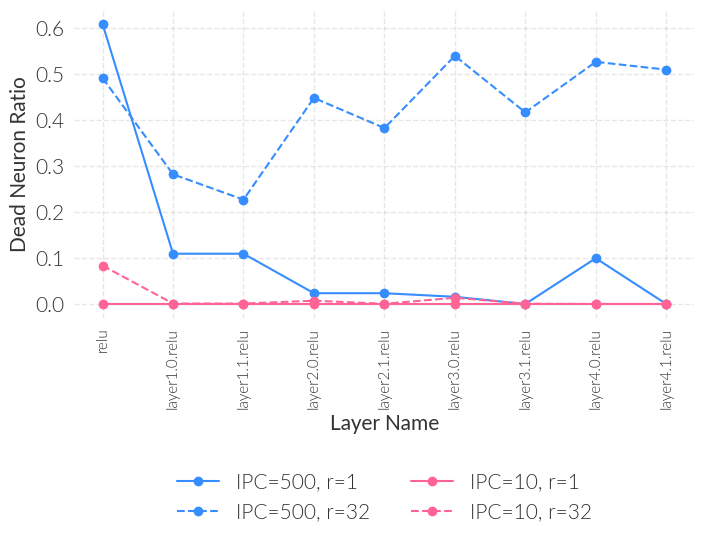

linear_cka


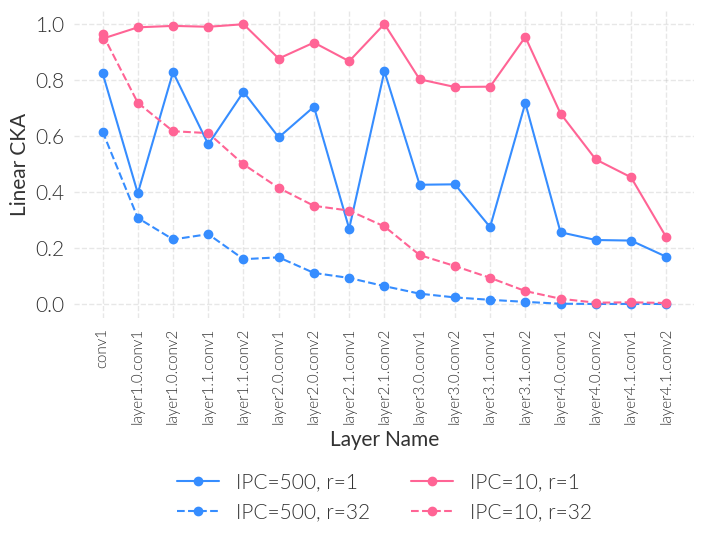

magnitude


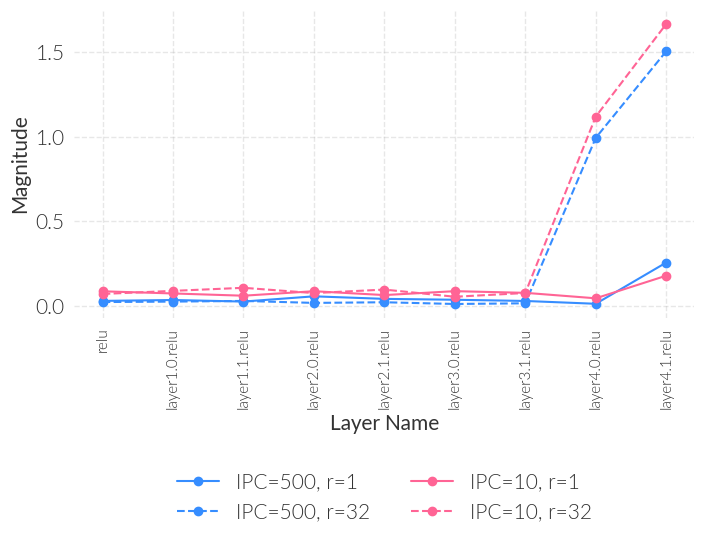

In [5]:
import matplotlib.pyplot as plt
plt.style.use(f'{this_path.parent}/common.mplstyle')
plt.style.use(f'{this_path.parent}/line.mplstyle')

plt.rcParams.update({
    'font.size': 15,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    
    'lines.markersize': 6,
    'axes.labelsize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

NAME_SLICE = slice(17, None) 

metrics_info = [
    ("activation_rate", "layer"),
    ("dead_neuron_ratio", "layer"),
    ("linear_cka", "layer"),
    ("magnitude", "layer")
]


# 1つ目が色、2つ目が線種に対応します
lines = [ipc, red] 
# lines = ["train_ndata", "div"] 

# 利用可能なスタイルと色のリスト
available_linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (1, 1))]
available_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for key, idx in metrics_info:
    fig, ax = plt.subplots(figsize=(8, 4))

    # 値とスタイル/色のマッピングを保持する辞書とインデックスを初期化
    linestyle_map = {}
    style_idx = 0
    color_map = {}
    color_idx = 0

    first_data = runs_data[0][key][idx]
    common_layers = list(first_data.keys())
    short_labels = [name[NAME_SLICE] for name in common_layers]
    
    for run_data in runs_data:
        # 平均値(index 0) と 層別データ(index=idx) の取得
        avg_val = run_data[key]["avg"]
        data_dict = run_data[key][idx]
        values = list(data_dict.values())

        # ラベル作成: パラメータ情報 + 平均値
        label_parts = [f"{line}={run_data[line]}" for line in lines]
        # label_parts.append(f"avg={avg_val:.3f}")
        label_str = ", ".join(label_parts)

        # --- 1つ目の要素で「色（color）」を決定 ---
        color_val_key = lines[0]
        color_val = run_data[color_val_key]

        if color_val not in color_map:
            color_map[color_val] = available_colors[color_idx % len(available_colors)]
            color_idx += 1
        current_color = color_map[color_val]

        # --- 2つ目の要素で「線の形状（linestyle）」を決定 ---
        current_linestyle = '-' 
        if len(lines) > 1:
            style_val_key = lines[1]
            style_val = run_data[style_val_key]

            if style_val not in linestyle_map:
                linestyle_map[style_val] = available_linestyles[style_idx % len(available_linestyles)]
                style_idx += 1
            current_linestyle = linestyle_map[style_val]
        
        # プロット
        ax.plot(range(len(common_layers)), values, marker='o', 
                linestyle=current_linestyle, color=current_color, label=label_str)

    ax.set_xticks(range(len(common_layers)))
    ax.set_xticklabels(short_labels, rotation=90)

    print(key)
    # ax.set_title(key) # 第1要素(key)をタイトルに設定
    mapping = {"linear_cka": "Linear CKA", "activation_rate": "Activation Rate", "dead_neuron_ratio": "Dead Neuron Ratio", "magnitude": "Magnitude"}
    ax.set_xlabel("Layer Name")
    ax.set_ylabel(mapping.get(key, key))
    # ax.legend()
    # ax.legend(bbox_to_anchor=(0.8, 1), loc='upper left', borderaxespad=0)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.44), ncol=2, frameon=False)
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=2, frameon=False)

    plt.savefig(f"{key}_bar.svg", bbox_inches='tight')
    plt.show()

In [6]:
import numpy as np

for run_data in runs_data:
    print(f"ipc={run_data[ipc]}, r={run_data[red]}")
    ind = "oracle"
    pathinfo_l = np.array(run_data["eval"][ind]["acc"])
    print(f"{ind}: {pathinfo_l}")
    ind = "ens"
    pathinfo_l = np.array(run_data["eval"][ind]["acc"])
    print(f"{ind}: {pathinfo_l}")
    
    # print(path_losses.min())

ipc=500, r=1
oracle: 0.7387999892234802
ens: 0.7387999892234802
ipc=500, r=32
oracle: 0.9912999868392944
ens: 0.6651999950408936
ipc=10, r=1
oracle: 0.12939999997615814
ens: 0.12939999997615814
ipc=10, r=32
oracle: 0.9983999729156494
ens: 0.2321999967098236


Plotting Average Bar Chart for: activation_rate


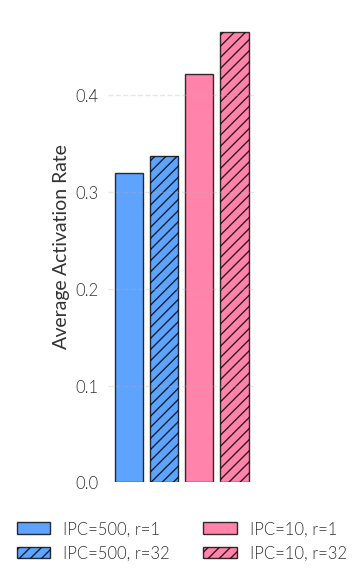

Plotting Average Bar Chart for: dead_neuron_ratio


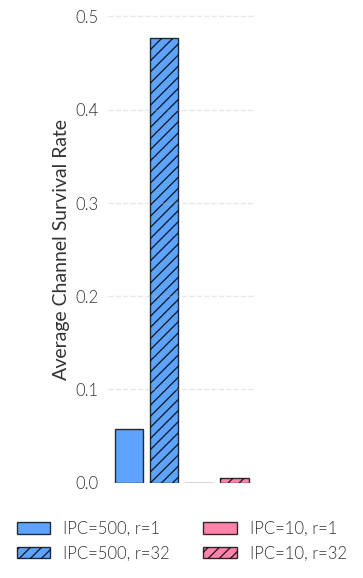

Plotting Average Bar Chart for: linear_cka


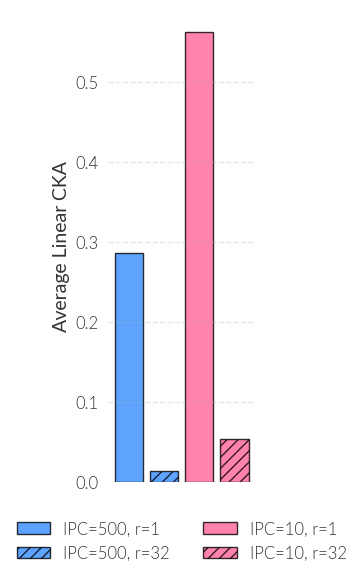

Plotting Average Bar Chart for: magnitude


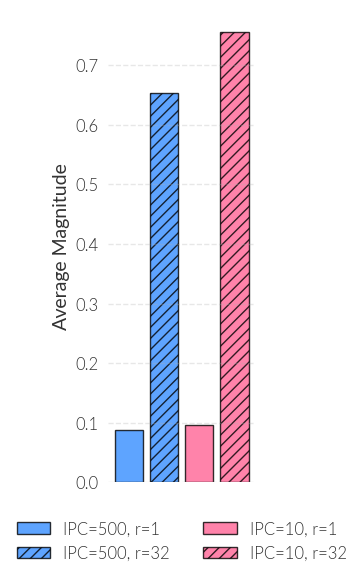

In [7]:
import matplotlib.pyplot as plt

# --- スタイル設定 (共通) ---
plt.rcParams.update({
    'font.size': 14,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'lines.linewidth': 2.5,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# メトリクス情報 (棒グラフでは idx は使用しませんが、ループ構造維持のため残します)
metrics_info = [
    ("activation_rate", "layer"),
    ("dead_neuron_ratio", "layer"),
    ("linear_cka", "layer"),
    ("magnitude", "layer")
]

mapping = {"linear_cka": "Linear CKA", "activation_rate": "Activation Rate", "dead_neuron_ratio": "Channel Survival Rate", "magnitude": "Magnitude"}

# ユーザー設定パラメータ
# lines = [ipc, red] 
# available_colors は既存のものを使用

# ★棒グラフ用の模様（ハッチング）リスト
# ''(無地), '///'(斜線), '...'(ドット), 'xxx'(クロス), '\\\'(逆斜線), '***'(星)
available_hatches = ['', '///', '...', 'xxx', '\\\\\\', '***']
available_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for key, _ in metrics_info:
    fig, ax = plt.subplots(figsize=(3, 6))

    # マッピング用辞書の初期化
    color_map = {}
    color_idx = 0
    hatch_map = {}
    style_idx = 0

    # 各Runのデータをプロット
    for run_i, run_data in enumerate(runs_data):
        # 平均値の取得
        avg_val = run_data[key]["avg"]

        # ラベル作成
        label_parts = [f"{line}={run_data[line]}" for line in lines]
        label_str = ", ".join(label_parts)

        # --- 1. 色の決定 (lines[0]) ---
        color_val_key = lines[0]
        color_val = run_data[color_val_key]

        if color_val not in color_map:
            color_map[color_val] = available_colors[color_idx % len(available_colors)]
            color_idx += 1
        current_color = color_map[color_val]

        # --- 2. 模様(ハッチング)の決定 (lines[1]) ---
        current_hatch = '' # デフォルトは無地
        if len(lines) > 1:
            style_val_key = lines[1]
            style_val = run_data[style_val_key]

            if style_val not in hatch_map:
                hatch_map[style_val] = available_hatches[style_idx % len(available_hatches)]
                style_idx += 1
            current_hatch = hatch_map[style_val]

        # --- 棒グラフのプロット ---
        # edgecolor='black' にすることで、色が薄い場合でも模様がはっきり見えます
        ax.bar(run_i, avg_val, 
               color=current_color, 
               hatch=current_hatch, 
               edgecolor='black', # 枠線とハッチングの色
               linewidth=1.0,
               alpha=0.8,         # 少し透明にして重なりやグリッドを見やすく
               label=label_str)

    # グラフ装飾
    print(f"Plotting Average Bar Chart for: {key}")
    ax.set_ylabel(f"Average {mapping.get(key, key)}")
    # ax.set_xlabel("Run Configuration")
    
    # X軸の目盛りは意味がない（凡例で識別する）ため非表示にするか、Run IDを表示
    ax.set_xticks([]) 
    
    # 凡例の設定 (グラフの外側に配置)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)
    
    plt.tight_layout()
    plt.show()

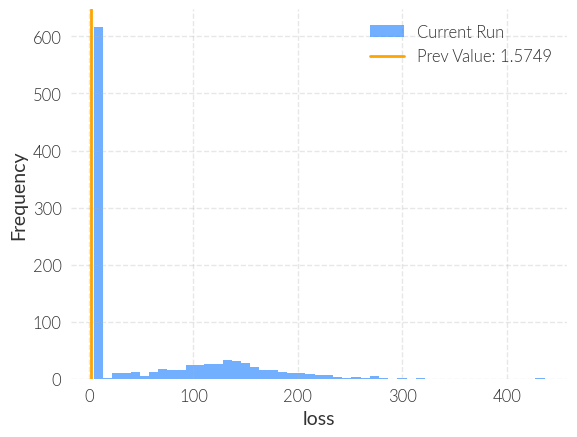

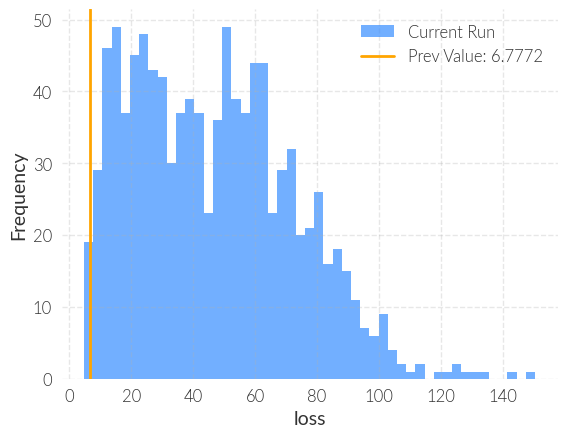

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 変数設定（環境に合わせて適宜変更してください）
metric = "loss"
use_log_scale = False
num_bins = 50

# 前のイテレーションから値を引き継ぐための変数
stored_ref_value = None

for run_data in runs_data:
    path_eval = np.array(run_data["eval"]["path"][metric])
    
    # 配列が空の場合はスキップ
    if path_eval.size == 0:
        continue

    min_val = np.min(path_eval)
    max_val = np.max(path_eval)
    
    # 値が1種類（分散0）かどうかを判定
    is_single_value = (min_val == max_val)

    if is_single_value:
        # 値が1つの場合：グラフを表示せず値を保持し、次のループへ
        stored_ref_value = min_val
        continue

    # 値が分布している場合：ヒストグラムを描画
    if use_log_scale:
        # 0以下の値が含まれる場合の対数計算エラー回避
        valid_min = max(min_val, 1e-10)
        bins = np.logspace(np.log10(valid_min), np.log10(max_val), num_bins)
    else:
        bins = np.linspace(min_val, max_val, num_bins)
        
    plt.hist(path_eval, bins=bins, alpha=0.7, label='Current Run')

    # 前のイテレーションで保持された値がある場合、垂直線を描画
    if stored_ref_value is not None:
        plt.axvline(
            x=stored_ref_value,
            color='orange',
            linestyle='-',
            linewidth=2,
            label=f'Prev Value: {stored_ref_value:.4f}'
        )
        # 描画後はリセット（次のグラフに持ち越さないため）
        stored_ref_value = None

    if use_log_scale:
        plt.xscale('log')
    else:
        plt.xscale('linear')

    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.legend()
    
    plt.show()

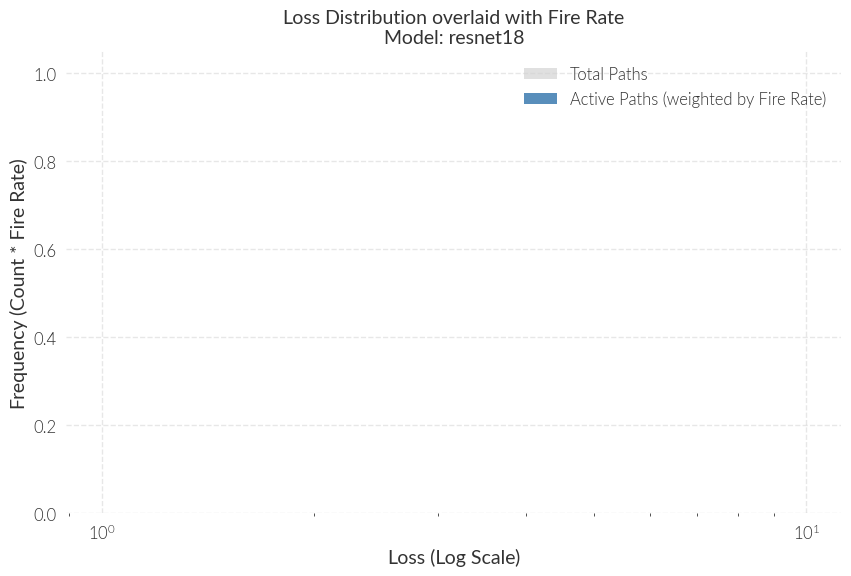

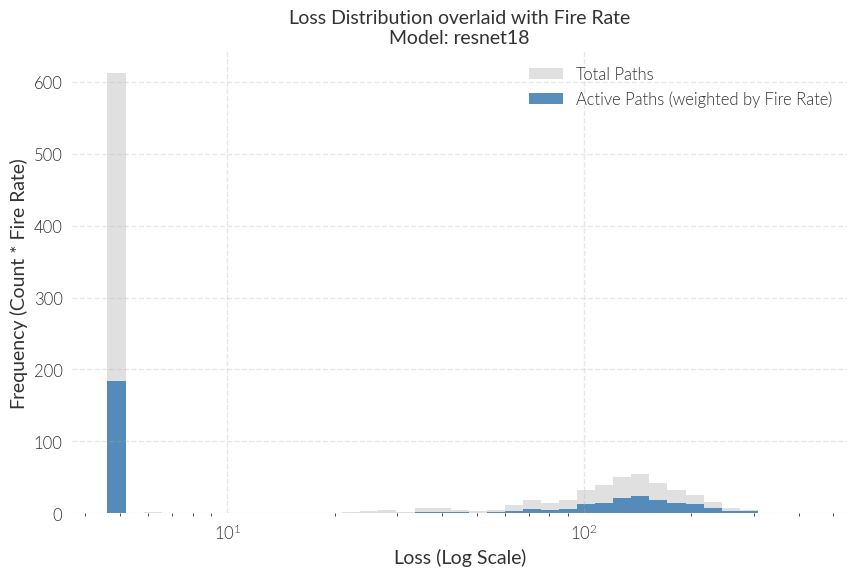

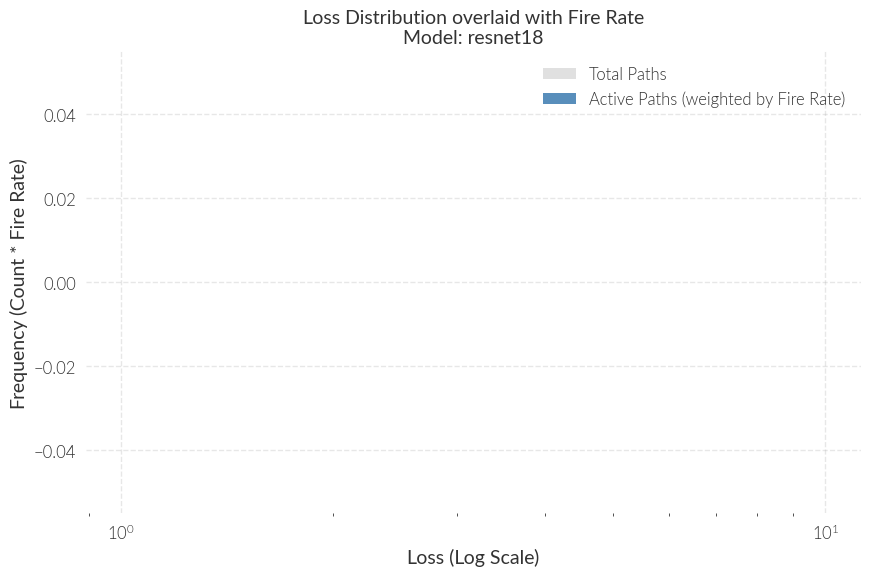

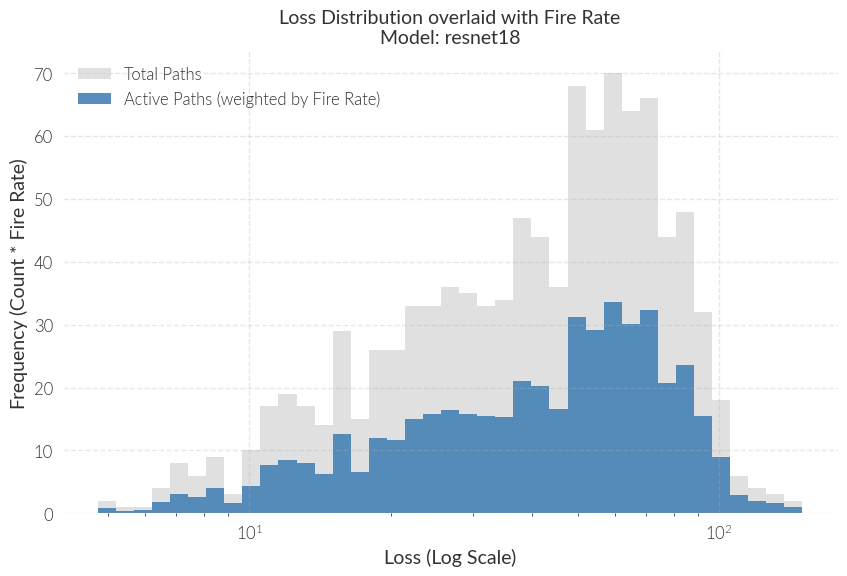

In [9]:
import matplotlib.pyplot as plt
import numpy as np

for run_data in runs_data:
    # データの取得
    # Loss: (num_groups,)
    path_losses = np.array(run_data["eval"]["path"]["loss"])
    
    # Fire Rate: (num_groups,) 
    # Analyzer.calc_fire_rateでwith_path=Trueにしているため取得可能
    path_rates = np.array(run_data["activation_rate"]["path"])

    # ビンの設定（対数軸用）
    # 最小値が0の場合のlog10エラーを防ぐため、微小値を加えるか、範囲を制限する
    min_val = max(path_losses.min(), 1e-8)
    max_val = path_losses.max()
    bins = np.logspace(np.log10(min_val), np.log10(max_val), 40)

    plt.figure(figsize=(10, 6))

    # 1. 全パス数の分布（薄い色で背景に表示）
    # これが分母（そのLoss帯に存在する全パス数）に相当します
    plt.hist(path_losses, bins=bins, color='lightgray', alpha=0.7, label='Total Paths')

    # 2. 発火率で重み付けした分布（濃い色で手前に表示）
    # これが分子（そのLoss帯での実質的な稼働パス数）に相当します
    # weights引数を使うことで、単なるカウントではなく、rateの合計値が高さになります
    plt.hist(path_losses, bins=bins, weights=path_rates, color='steelblue', alpha=0.9, label='Active Paths (weighted by Fire Rate)')

    # 軸・ラベル設定
    plt.xscale('log')
    plt.xlabel("Loss (Log Scale)")
    plt.ylabel("Frequency (Count * Fire Rate)")
    plt.title(f"Loss Distribution overlaid with Fire Rate\nModel: {run_data.get('model_arc', 'Unknown')}")
    plt.legend()
    
    plt.show()

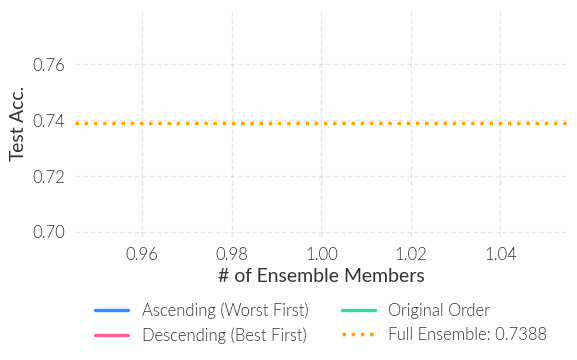

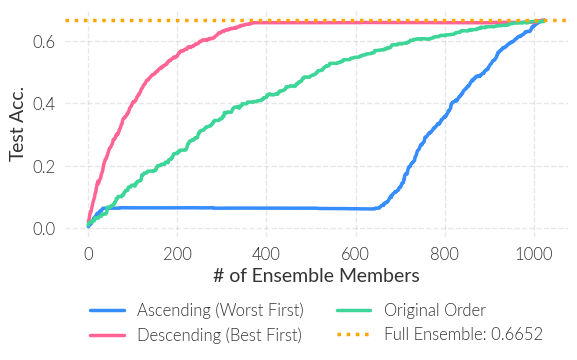

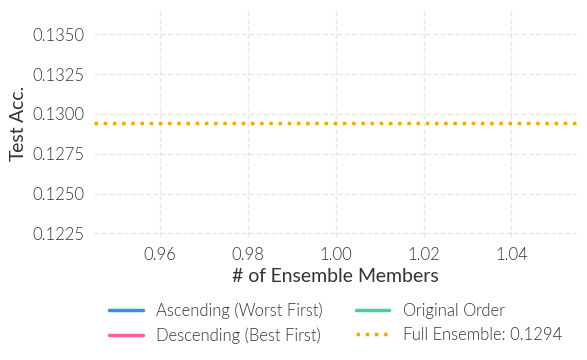

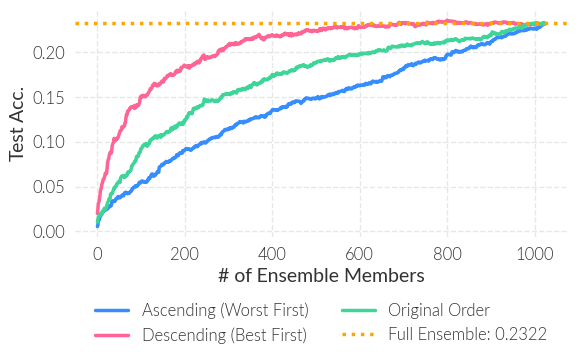

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# マッピング定義（キーは実際のデータのキーと一致させる）
LABEL_MAP = {
    "acc_asc": "Ascending (Worst First)",
    "acc_desc": "Descending (Best First)",
    "original": "Original Order",
    "random": "Random Order",
}

plt.rcParams.update({
    'legend.fontsize': 12,
})

target_metric = "acc"

for run in runs_data:
    eval_res = run.get("eval", {})
    cum_data = eval_res.get("cumulative", {})
    ens_val = eval_res.get("ens", {}).get(target_metric)

    if not cum_data:
        continue

    plt.figure(figsize=(6, 4))

    for mode, metrics in sorted(cum_data.items()):
        # mode自体が "acc_asc" 等になっているため、loss系は除外
        if "loss" in mode: 
            continue
        
        # ターゲット指標のデータが含まれているか確認
        if target_metric not in metrics:
            continue

        y = np.array(metrics[target_metric])
        if y.size == 0:
            continue

        # 【修正点】: キーを加工せず、そのままマッピングに使用
        label = LABEL_MAP.get(mode, mode)
        
        plt.plot(np.arange(1, len(y) + 1), y, label=label)

    if ens_val is not None:
        plt.axhline(y=ens_val, color='orange', linestyle=':', label=f'Full Ensemble: {ens_val:.4f}')

    plt.xlabel("# of Ensemble Members")
    plt.ylabel("Test Acc.")
    # print(target_metric.capitalize())
    # plt.title(f"Cumulative Ensemble Transition ({target_metric.capitalize()})")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)
    plt.tight_layout()
    plt.savefig(f"cumulative_acc_ipc{run['run_id']}.svg", bbox_inches='tight')
    plt.show()